# 드론 통신 방식
- 드론 통신 구조(WiFi 제어) 흐름 실습

---  


## 1부. 통신의 역사 — "어떻게 여기까지 왔을까?"

- 인류는 먼 거리에 정보를 전달하기 위해 끊임없이 기술을 발전시켜왔다. 
- 봉화에서 전신, 라디오, 인터넷을 거쳐 지금의 WiFi 드론 제어까지, 통신 기술의 흐름을 타임라인으로 먼저 살펴보자.
- <img src=attachment:31f22063-d45f-4c97-84ee-060b49533393.png width=1000>

---

## 2부. 통신의 기본 개념 — "데이터는 어떻게 이동할까?"

* 통신의 세 가지 핵심 개념
* **송신자(Sender) → 채널(Channel) → 수신자(Receiver)**
* 드론 제어에서는 <font color=red>스마트폰/노트북이 송신자</font>, <font color=green>WiFi 전파가 채널</font>, <font color=blue>드론이 수신자</font>

또한 통신 방향에 따라 세 가지 방식 있음

<span style="position:left;display:inline-block">

| 방식 | 설명 | 드론 예시 |
|------|------|-----------|
| 단방향 (Simplex) | 한 방향만 전송 | 구형 RC 조종기 → 드론 |
| 반이중 (Half-Duplex) | 번갈아 가며 송수신 | 무전기처럼 "오버" 후 교대 |
| 전이중 (Full-Duplex) | 동시에 송수신 | WiFi 드론: 명령 전송 + 영상 수신 동시에 |

</span>

<font color=blue><b>WiFi 드론은 전이중 방식이기 때문에 조종 명령을 보내면서 동시에 카메라 영상을 받아볼 수 있음</b></font>

---

## 3부. WiFi 통신의 구조 — "드론과 스마트폰이 대화하는 방법"

<h3>WiFi 드론 제어의 전체 통신 흐름 구조 다이어그램</h3>  
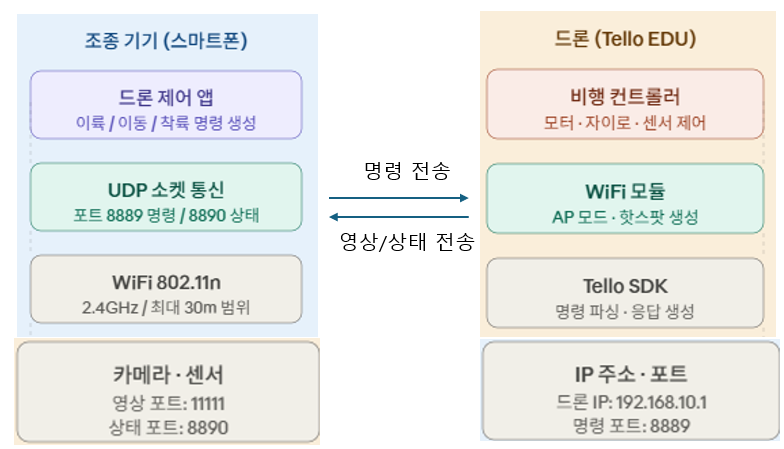  

---  

<h3>유선/무선 랜카드 종류</h3>  
<img src=attachment:cb4ce366-02a3-499e-96af-01d5740d535f.png style="border:1px solid blue;" width=800px>  

---  

<h3>랜카드 신호</h3>  

* NIC(Network Interface Card)에 부여되는 고유 식별 번호
* MAC주소(6바이트) : **00-00-00-00-00-00**
  > 앞 3바이트 : OUI(Organizationally Unique Identifier)로서 제조사 식별  
  > 뒤 3바이트 : NIC 고유번호로 제조사 내부적으로 부여하는 일련번호
* 랜카드가 유선인 경우 **이더넷**, 무선인 경우 **Wi-Fi**, 그외에도 **블루투스** 등이 있음
* <img src=attachment:a528af0d-bb92-4839-b339-48aca29d9f96.png>
  


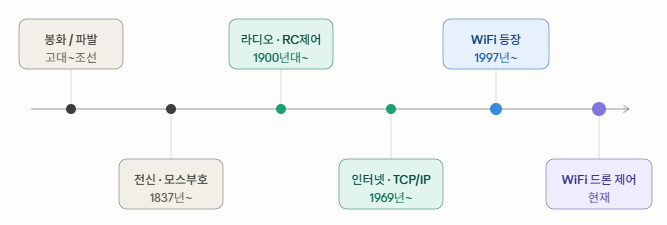
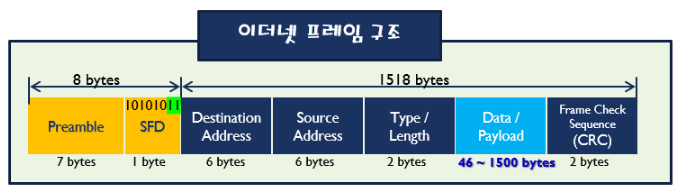
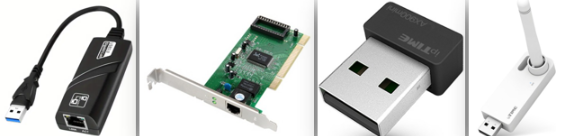

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  &ensp;
</div>

### 4부. Tello SDK 실전 명령어 — "파이썬으로 드론에게 말 걸기"

* 수업에서 사용할 핵심 개념 : UDP 소켓 통신
* Tello SDK 명령어 정리
- **선수조건**
  > (1) Tello EDU 드론/배터리 삽입/전원 켜기  
  > (2) 노트북과 드론 WiFi 페이링  

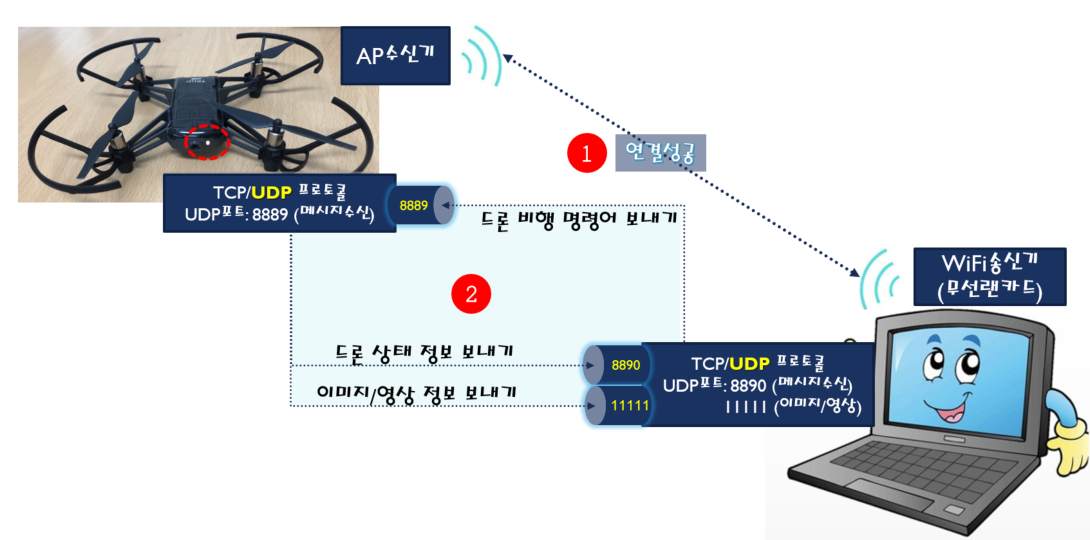  


## TCP vs UDP 기본 개념 비교

<span style="position:left;display:inline-block;">

| 항목 | TCP | UDP |
|------|-----|-----|
| 연결 방식 | 연결 지향 (3-way handshake) | 비연결 |
| 신뢰성 | 높음 (전송 보장) | 낮음 (전송 보장 없음) |
| 속도 | 느림 | 빠름 |
| 순서 보장 | O | X |
| 용도 | HTTP, FTP, 채팅 | 게임, 스트리밍, DNS |
| 소켓 타입 | <font color=red><b>SOCK_STREAM</b></font> | <font color=red><b>SOCK_DGRAM</b></font> |

</span>

---

## TCP vs UDP 코드 흐름 비교

```
====================TCP통신===============================

 TCP 서버                      TCP 클라이언트
─────────────────────         ─────────────────────
socket()                      socket()
bind()                        
listen()                      
accept()   ← 연결 대기         connect()  ← 연결 필수
recv()                        send()  
send()                        recv()
close()                       close()

====================UDP통신===============================

 UDP 서버                      UDP 클라이언트
─────────────────────         ─────────────────────
socket()                      socket()
connect()  ← 연결 필수         
recvfrom()                    sendto()     ← 바로 전송
sendto()                      recvfrom()   ← 바로 전송
close()                       close()

========================================================
```

---

## 언제 무엇을 쓸까?

```
TCP 사용 ✅               UDP 사용 ✅
─────────────────         ─────────────────
웹 서버 / API             실시간 게임
파일 전송                 영상 스트리밍
로그인 / 인증             DNS 조회
채팅 앱                   IoT 센서 데이터
이메일 (SMTP)             음성 통화 (VoIP)
```

<a href="tcp-server.ipynb" target=_blank alt=TCP><font color=blue><b>■ TCP 서버</b></font></a>  
<a href="tcp-client.ipynb" target=_blank alt=TCP><font color=blue><b>■ TCP 클라이언트</b></font></a>  

---  

<a href="tcp-server.ipynb" target=_blank alt=TCP><font color=blue><b>■ UDP 서버</b></font></a>  
<a href="tcp-client.ipynb" target=_blank alt=TCP><font color=blue><b>■ UDP 클라이언트</b></font></a>  

---


<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  &ensp;
</div>

## [방법1] 노트북과 노트북을 애드훅(Ad-hoc Mode) 방식으로 연결하기
1. 무선랜 상태 확인: `netsh wlan show hostednetwork`

2. 가상 무선 네트워크 생성: `netsh wlan set hostednetwork mode=allow ssid=myadhoc key="12345678"`

3. 가상 무선 네트워크 시작: `netsh wlan start hostednetwork`

4. 무선랜 종료 : `netsh wlan stop hostednetwork`

   > netsh wlan show drivers

## [방법2] 무선랜 핫스팟 사용하기
1. 설정(win + I)
2. 네트워크 및 인터넷
3. 모바일 핫스팟 켜기(`SSID`, `PW설정`)

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  &ensp;
</div>

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;text-align:center">
  &ensp;<h2>여기서부터는 Tello 드론과 노트북으로 연결하여 작업하기</h2><br>  
</div>

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  &ensp;
</div>

## 진행순서
* 선수조건
  > Tello 드론 배터리 충전 및 전원 켜기  
  > 노트북과 드론 페어링 진행  
* <img src=attachment:2c442fb2-eeeb-49a2-a834-5099cf7694b4.png> <img src=attachment:e4c9001b-e3f2-4eeb-93ff-78a448b32176.png> <img src=attachment:56cd46ae-78ec-4be8-b45f-8141bd497fdf.png> <img src=attachment:55940c72-050a-4c4d-8a58-47f37e82ca68.png> <img src=attachment:86e5e277-a325-4eb9-bebb-b931a0f91a01.png> <img src=attachment:18100815-190b-4c6e-b8d3-f19034fe387d.png> 

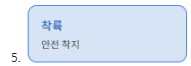
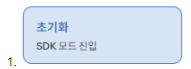
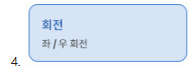
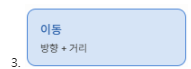
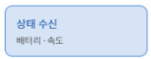
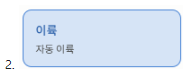

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  &ensp;
</div>

<div style="background-color: ivory; padding: 2px; border-radius: 1px;">
1. <img src=attachment:0eef8687-8fa9-4bb4-b559-b7c033b8deea.png>
</div>
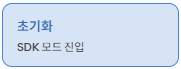

In [ ]:
# 선수작업: 
#   1. 드론 배터리 삽입
#   2. 드론과 노트북 WiFi 페이링 완료
#
# (중요) 선수작업 완료 후 아래 코드 실행:   UDP 소켓 생성 > "command" 전송하여 드론 SDK모드 활성화 진행
# 드론 IP: 192.169.10.1, PORT: 8889
import socket

# UDP 소켓 생성 : 
sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM) 
sock.bind(('', 9000))  # 내 수신 포트

DRONE_IP = '192.168.10.1'
DRONE_PORT = 8889

def send(cmd):
    sock.sendto(cmd.encode(), (DRONE_IP, DRONE_PORT))
    resp, _ = sock.recvfrom(1024)
    return resp.decode()

# SDK 모드 진입 (반드시 먼저!)
print(send('command'))  # 응답: 'ok'

<div style="background-color: ivory; padding: 2px; border-radius: 1px;">
2. <img src=attachment:e9bfd59b-f907-49aa-b4b5-70338f298243.png>
</div>
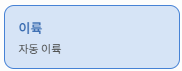

In [ ]:
# "takeoff" 명령 전송하여 드론 이륙
response = send('takeoff')
print(f"이륙 응답: {response}")
# 출력: 이륙 응답: ok

# 잠깐 공중에 머무르기
import time
time.sleep(3)  # 3초 대기

<div style="background-color: ivory; padding: 2px; border-radius: 1px;">
3. <img src=attachment:1f994326-059a-475a-abb5-29204bb8e76d.png>
</div>
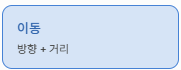

In [ ]:
# 방향 명령: up/down/left/right/forward/back
# 앞으로 30cm 이동
send('forward 30')

# 오른쪽으로 30cm
send('right 30')

# 위로 50cm 상승
send('up 50')

# 여러 동작을 순서대로 실행
commands = ['left 30', 'back 30',
            'down 30', 'right 30']
for cmd in commands:
    send(cmd)
    time.sleep(1.5)  # 각 동작 완료 대기

<div style="background-color: ivory; padding: 2px; border-radius: 1px;">
4. <img src=attachment:59bec79c-9979-48b9-8d3f-244228d05723.png>
</div>
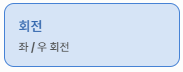

In [ ]:
# 회전 명령: cw(시계방향), ccw(반시계방행) 0 ~ 360
# 시계 방향으로 90도 회전
send('cw 90')
time.sleep(1)

# 반시계 방향으로 45도 회전
send('ccw 45')
time.sleep(1)

# 제자리에서 한 바퀴 회전
send('cw 315')
time.sleep(3)

<div style="background-color: ivory; padding: 2px; border-radius: 1px;">
&ensp;<img src=attachment:d37a5715-baff-4af6-a4db-ae79e1b52f7e.png><br>
<img src=attachment:118d682c-85e8-4bb9-b97f-34247f7812aa.png>
</div>
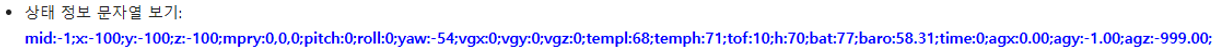
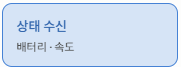

In [ ]:
# 드론 상태 수신 : 드론의 SDK 버전, SN, 배터리, 속도, 높이 등 상태를 보고
data, _ = status_sock.recvfrom(1024)
info = data.decode()
# 예시: "bat:85;h:30;vgx:0;..."
#items = {}
#  for item in info.split(";"):
#    if ":" in item:
#      k, v = item.split(":")
#      items[k] = v
#위 items 코드를 comprehension으로 정의 (예로 리스트 경우, [표현식 for 변수 in 반복가능객체]
#예  data = [ x for x in range(10) ]  => [0,1,2,3,...,9]
items = dict(x.split(':')
    for x in info.split(';')
    if ':' in x)
print("드론의 상태 정보")
print(f" 배터리: {items.get('bat')}%,"
      f" 고도: {items.get('h')}cm,"
      f" 속도: {items.get('h')}cm/s,"
      f" 비행누적시간: {items.get('tof')}sec")


<div style="background-color: ivory; padding: 2px; border-radius: 1px;">
5. <img src=attachment:9600159c-a4a2-487b-801f-4a20e23aba21.png>
</div>
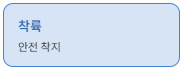

In [ ]:
# 착륙 명령: land
# 정상 착륙
response = send('land')
print(f"착륙 응답: {response}")
# 출력: 착륙 응답: ok

# 비상 정지 (주의: 추락할 수 있음!)
# send('emergency')

# 소켓 정리
sock.close()

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  &ensp;
</div>

### 핵심 정리

**오늘 배운 핵심 3가지**

1. 모든 통신은 **송신 → 채널 → 수신**의 구조를 가지며, WiFi 드론은 전이중 방식으로 명령과 데이터를 동시에 주고받는다.
2. Tello EDU드론은 WiFi AP 모드로 동작하며, **UDP 소켓 + 포트 번호**로 명령/상태/영상을 구분한다.
3. `socket.sendto()`로 문자열 명령을 보내면 드론이 파싱해 모터를 제어한다.
